# Data Smoothing and Differentiation

## Savitzky-Golay filters

### how it works

Data smoothing is a way of reducing time varying noise in measured data so as to reveal the underlying dependence of the measured variable on a different variable (such as an applied voltage or an external magnetic field). In most cases, the computer is acting as a digital low pass filter. It differs from an analog low pass output filter in that the filtering is done by us using a computer after the measurement is complete rather than by the instrument itself. 

Like the signal averaging done by a digital oscilloscope — the point by point averaging of a periodic signal — data smoothing seeks to separate random noise from a reproducible signal, but here the measured 'signal' to be smoothed is not assumed to be periodic, is not repeated,  and is in fact usually a function of a variable other than time.  An example would be the measurement of current as a function of applied voltage or a resistance as a function of magnetic field. 

In this getting start guide, we will focus on the use of a particularly useful and easy to use ready-made filter for data smoothing of $y(x_i)$ data **equally spaced** in $x_i):  the  [Savitzky-Golay](https://en.wikipedia.org/wiki/Savitzky%E2%80%93Golay_filter) low pass filter (Savitzky 1964, Steinier 1972). 

:::{warning}
If your (x,y) data is not equally spaced in $x$, you must first *interpolate* your data to generate equally spaced values in $x$ and $y$. You can do this creating a linear or cubic spline interpolation function. 
:::

The SVG filter works by fitting a subset of data points adjacent to a particular data point with a low-degree polynomial, evaluating the polynomial at that point, and then repeating the process for each data point. The set of points centered about a particular data point is called the *filter window* and the number of points in the filter window is called the *window length* (although width would seem more apt). 

The picture here might be  of a small window in a cabin looking out upon a nearby data stream. The window  reveals a small  subset of points at a time as the data "streams" by. The fit is carried out on the points seen through the window, and repeated for each point in the stream. 

So, for example, if we are measuring current $I(V)$ as a function of applied voltage $V$  from -10 to +30 V in equal steps of $c = 0.1$  volts, specifying a window length $L= 21$  points  and a second order polynomial fit ($n = 2$) would correspond to a fitting a quadratic function to a set of 21 points spanning a 2 V range centered about a particular data point (including that point), then repeating that process for each subsequent data point. In the SciPy implementation, this repeated fitting over a moving data stream is done automatically for us. 

:::{tip}
As a bonus, the SciPy Savitzky-Golay filter function ```scipy.signal.savgol_filter``` can also be used to numerically differentiate the smoothed data (again, provided the data is "equally spaced").  This is a particularly useful feature. 

For example, we might directly measure $I(V)$ for a particular non-ohmic device (such as a light bulb or a laser diode) but be more interested theoretically in the differential current $dI/dV$ as a function of applied voltage $V$. Experimentally, the noise fluctuations in a measurement of  $I(V)$ as a function of $V$ usually preclude a direct calculation of $dI/dV$. But if we  first smooth the data using a Savitzky-Golay filter to reduce the noise, a meaningful calculation of $dI/dV$ as a function of $V$ can now be carried out.  
:::


### requirements

1. the data points to be smoothed must  be *evenly spaced* ( in time, voltage, magnetic field, ...). If not, interpolate first! 
2. the *window length* $L$ must be an odd number
3. the polynomial order $n$  --- $n = 1$ for linear, $n = 2 $ for quadratic, $n = 3$ for cubic) must be less than the window length $L$: $n < L$.

 So if measurement is of $y(x)$, then $x_{i+1} - x_i = c$ where $c$ is a constant, and this must be true for all $i$ 

### how to choose $L$ and $n$

 In all data smoothing routines, there is a tradeoff between the degree of smoothing and the ability to resolve small features in the underlying signal; data smoothing is not a substitute for working as carefully as possible to minimize the measurement noise and maximize the accuracy and precision of the originally measured data. 
 
 In the end, the  'best values' for these parameters are usually determined by trial and error. Start with $n=2$ and increase $L$ as needed to improve the smoothing. If you feel that two many true fine details are being lost, change $n = 3$ and try again. 
 
 Keep track of the values used: for a smoothed function $y(x)$, the uncertainty $\delta x$ of your experiment is approximately the window width x data spacing:  $\delta x  \approx L c$. 

### implementation in Python

Here is some sample code that makes use of the function ```savgol_filter``` to generate a smoothed version of ```noisy_data```, where ```noisy data``` is an array of $y(x)$ values, the ```window width``` is $L$, the ```polynomial_order``` is $n$, and the ```data_spacing``` is $c$.  

Notice that you don't need to specify the x_array! YOu only need the y_array data and the x_array spacing $c$. 

In [1]:
# first, we import some needed Python modules 
import numpy as np # only need this once per program
import matplotlib as mpl
from matplotlib import pyplot as plt 

from scipy.signal import savgol_filter 

rng = np.random.default_rng() #rng stands for random number generator


In [2]:
# next we create a noisy signal to be smoothed or filtered

# Generate a noisy signal to be filtered.
x = np.linspace(-1, 1, 201)
y = (np.sin(2 * np.pi * 0.75 * x*(1-x) + 2.1) + 0.1*np.sin(2 * np.pi * 1.25 * x + 1) +
    0.18*np.cos(2 * np.pi * 3.85 * x))
noisy_data = y + (rng.random(len(x))-0.5) * 0.2 # random number is between 0 and 1, so subtract off 0.5 to all + and - values

print(x[1] - x[0] )

0.010000000000000009


In [3]:


window_width = 17      # set number of points over which data is fit and smoothed equal to 25
                       # window_width must be an odd number
polynomial_order = 2   # set order of polynominal used to fit data equal to 2 
                       # polynomial_order must be less than window_width

data_spacing = 0.01     # data_spacing = x_1 - x_0 for data y(x_0), y(x_1), ....

smoothed_data   = savgol_filter(noisy_data, window_width, polynomial_order) #smooth data
data_derivative = savgol_filter(noisy_data, window_width, polynomial_order, deriv = 1, delta = 0.1) #take 1st derivative, assuming spacing in x = 0.1 for data points y(x_0), y(x_1), ... 


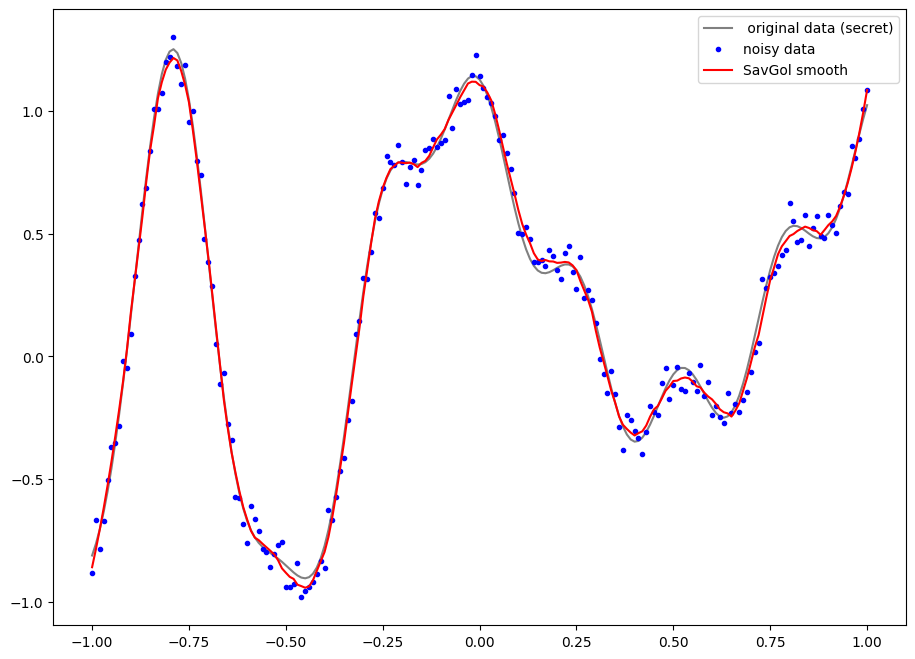

In [4]:
# make a plot

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(x, y, color = 'grey', label = " original data (secret)")
plt.plot(x, noisy_data,".", 
    color = 'blue', 
    label = 'noisy data ')
plt.plot(x, smoothed_data,  color = 'red', label = 'SavGol smooth ')
plt.legend(loc = "best")
plt.show()

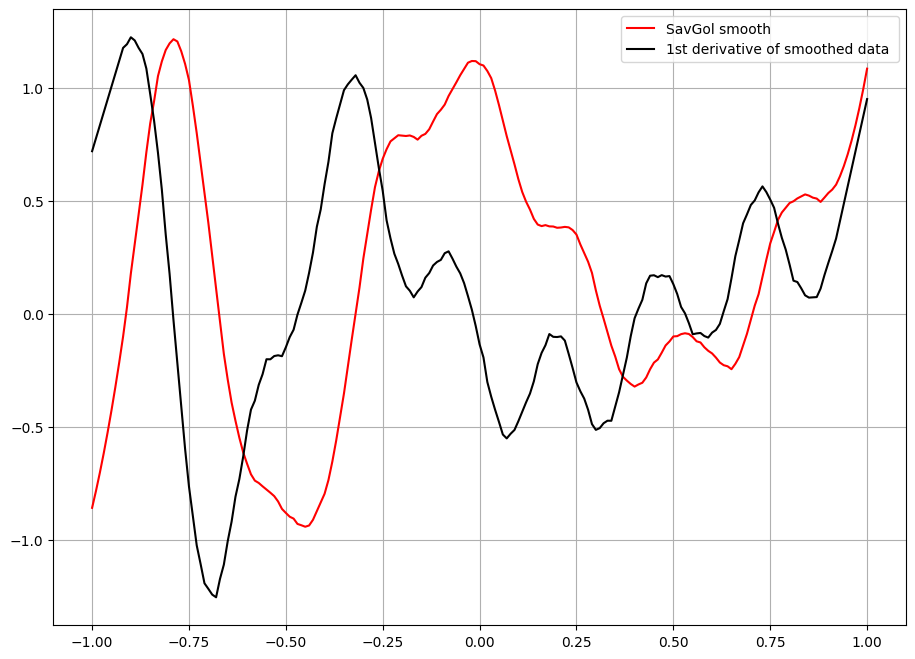

In [5]:
# make a plot of the 1st derivative

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(x, smoothed_data,  color = 'red', label = 'SavGol smooth ')
plt.plot(x, data_derivative,  color = 'black', label = '1st derivative of smoothed data ')
plt.legend(loc = "best")
plt.grid()
plt.show()

Since for real experimental data the original 'clean signal' is unknown, the degree of smoothing is always a matter of judgement. A comparison of several different smoothing values (not shown) can be useful in discerning the best choice of parameters and the effective resolution of your processed data (and any derivatives) . 

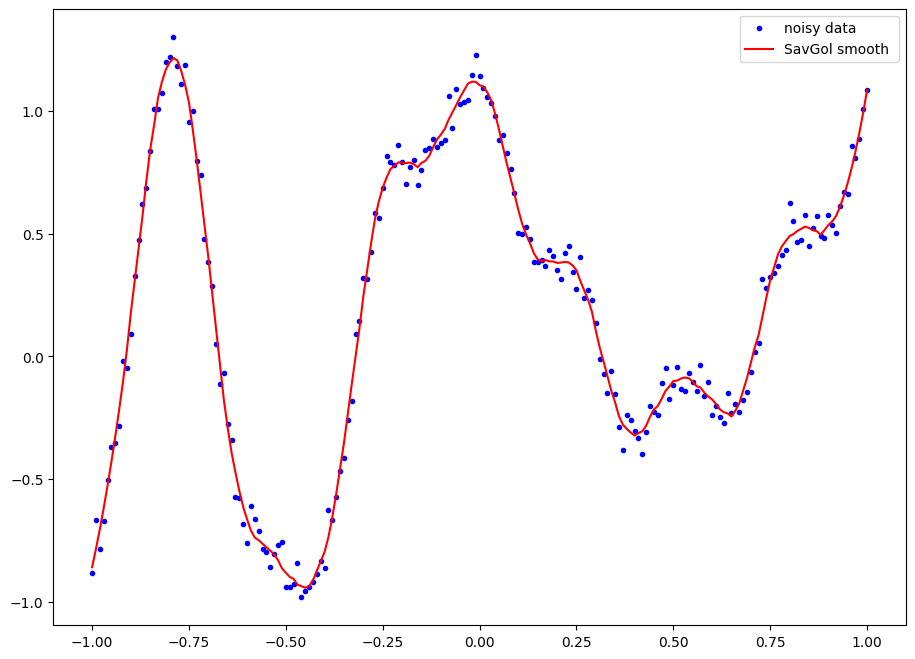

In [6]:
# make a plot without the unknown original clean data

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
# plt.plot(x, y, color = 'grey', label = " original data (secret)")
plt.plot(x, noisy_data,".", 
    color = 'blue', 
    label = 'noisy data ')
plt.plot(x, smoothed_data,  color = 'red', label = 'SavGol smooth ')
plt.legend(loc = "best")
plt.show()

Looking at the graph above, for example, you might choose heavier smoothing . Let's compare

In [7]:
new_window_width = 25      # set number of points over which data is fit and smoothed equal to 25
                       # window_width must be an odd number
polynomial_order = 2   # set order of polynominal used to fit data equal to 2 
                       # polynomial_order must be less than window_width

data_spacing = 0.01     # data_spacing = x_1 - x_0 for data y(x_0), y(x_1), ....

new_smoothed_data   = savgol_filter(noisy_data, new_window_width, polynomial_order) #smooth data


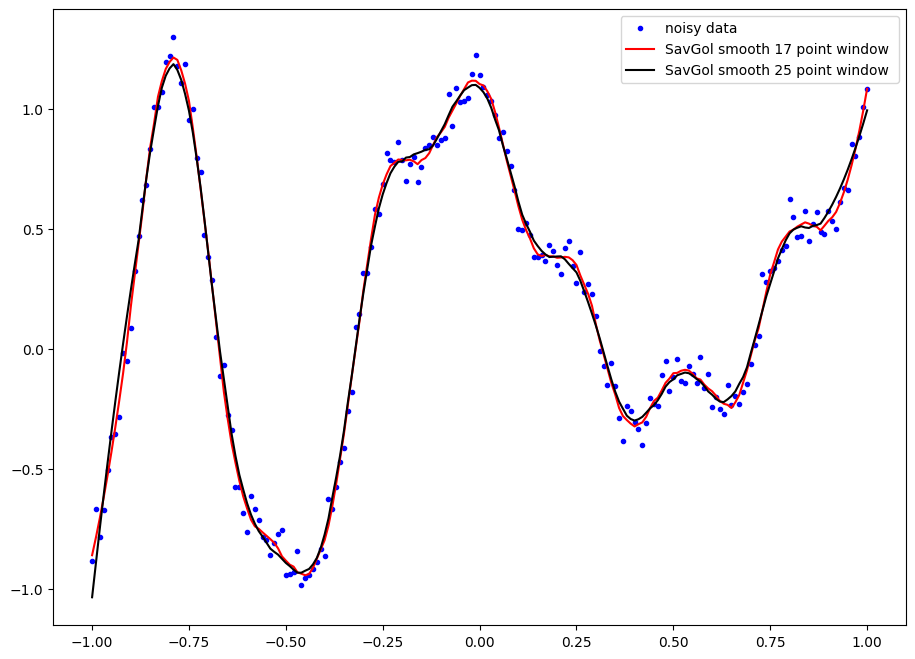

In [8]:
# make a plot without the unknown original clean data

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
# plt.plot(x, y, color = 'grey', label = " original data (secret)")
plt.plot(x, noisy_data,".", 
    color = 'blue', 
    label = 'noisy data ')
plt.plot(x, smoothed_data,  color = 'red', label = 'SavGol smooth 17 point window ')
plt.plot(x, new_smoothed_data,  color = 'black', label = 'SavGol smooth 25 point window ')
plt.legend(loc = "best")
plt.show()

The black curve is a smoother curve through the noisy points but is it better? Your decision! 

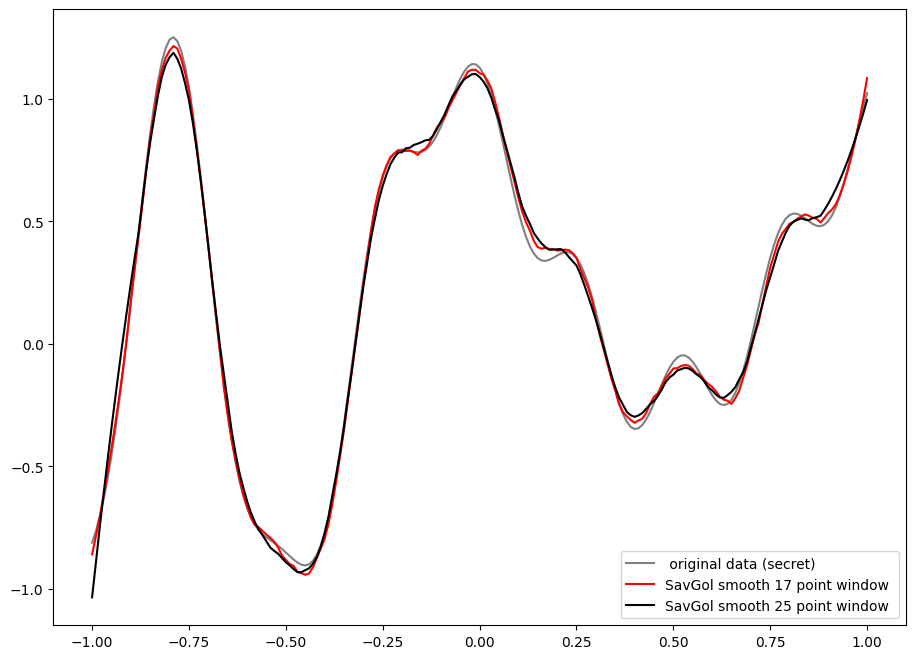

In [9]:
# make a plot without the unknown original clean data

plt.figure(figsize = (11,8))                  #specify figure size as 7 x 5 inches
                                             #for default size, type plt.figure() 

# plot original data 
plt.plot(x, y, color = 'grey', label = " original data (secret)")
plt.plot(x, smoothed_data,  color = 'red', label = 'SavGol smooth 17 point window ')
plt.plot(x, new_smoothed_data,  color = 'black', label = 'SavGol smooth 25 point window ')
plt.legend(loc = "best")
plt.show()

# Assignment

## tasks

repeat this smoothing using a cubic ($n = 3$) smoothing function instead of a quadratic ($n=2$). Find a smoothing window length $L$ that produces a smoothed curve  that you think best matches the original (secret) data. Plot it! 

Then compare your preferred smoothed curve and the noisy data curve by plotting both on a new plot (without the original secret data). What do you think? Is it a plausible "fit" to the noisy data?  

## formatting

This is your lab analysis notebook, so 

1. Create a new notebook for this assignment.
2. Add your name to the assignment.
3. Give the notebook a new file name.

General guidance: 
- You may copy from this notebook any Python code you need but **do not** include the introductory text.
- Instead, replace these examples with your own data smoothing results (for polynomial order $n = 3$)
- insert your own explanations as to what you are doing.
- copy existing examples  (for polynomial order $n = 2$) from this notebook only if and when needed for comparison to your own results (for polynomial order $n = 3$)
- as always, be sure the notebook can run without error if you select ```Restart Kernel and Run all Cells``` from the Kernel menu. 
